# Módulo 30 - K-Means
**Atividade:**

Nesta tarefa, vamos explorar o algoritmo de clustering K-means aplicado a um contexto diferente do usual. Em vez de segmentar perfis de viajantes ou clientes de e-commerce, vamos usar dados biológicos para segmentar diferentes espécies de pinguins com base em características físicas. Esta abordagem destaca a versatilidade do K-means para diversas áreas além de vendas e marketing.

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.

species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita

In [47]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np

In [3]:
penguins = sns.load_dataset('penguins')

In [4]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.

In [33]:
# verificar missing
print("Missing por coluna:\n", penguins.isnull().sum())

# criar cópia e remover linhas com qualquer valor faltante
df_clean = penguins.copy().dropna().reset_index(drop=True)

# selecionar apenas colunas numéricas para KMeans
df_num = df_clean.select_dtypes(include=['float64','int64']).copy()

print("\nShape original:", penguins.shape)
print("Shape após dropna:", df_clean.shape)
print("Colunas numéricas para clustering:", df_num.columns.tolist())

df_num.head()

Missing por coluna:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Shape original: (344, 7)
Shape após dropna: (333, 7)
Colunas numéricas para clustering: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,36.7,19.3,193.0,3450.0
4,39.3,20.6,190.0,3650.0


# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? Se sim, quantos?

#### Agrupamentos visíveis

Nos relacionamentos entre as variáveis, é possível visualizar até três agrupamentos visíveis, condizentes com as 3 espécies de pinguins.
Em outros relacionamentos é possível visualizar que exista sobreposição de entre grupos, pois tem uma densidade muito maior de pontos.
podemos considerar de K = 3


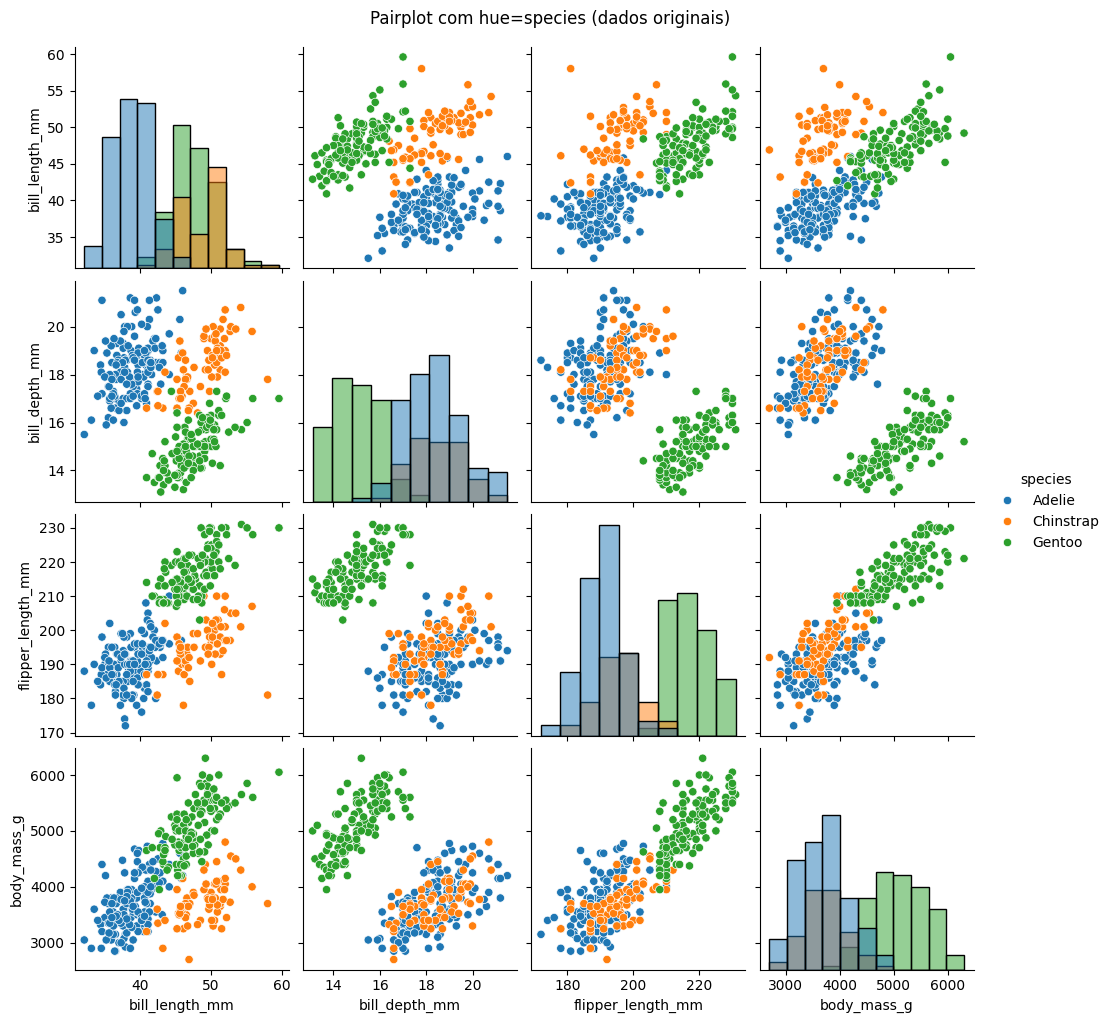

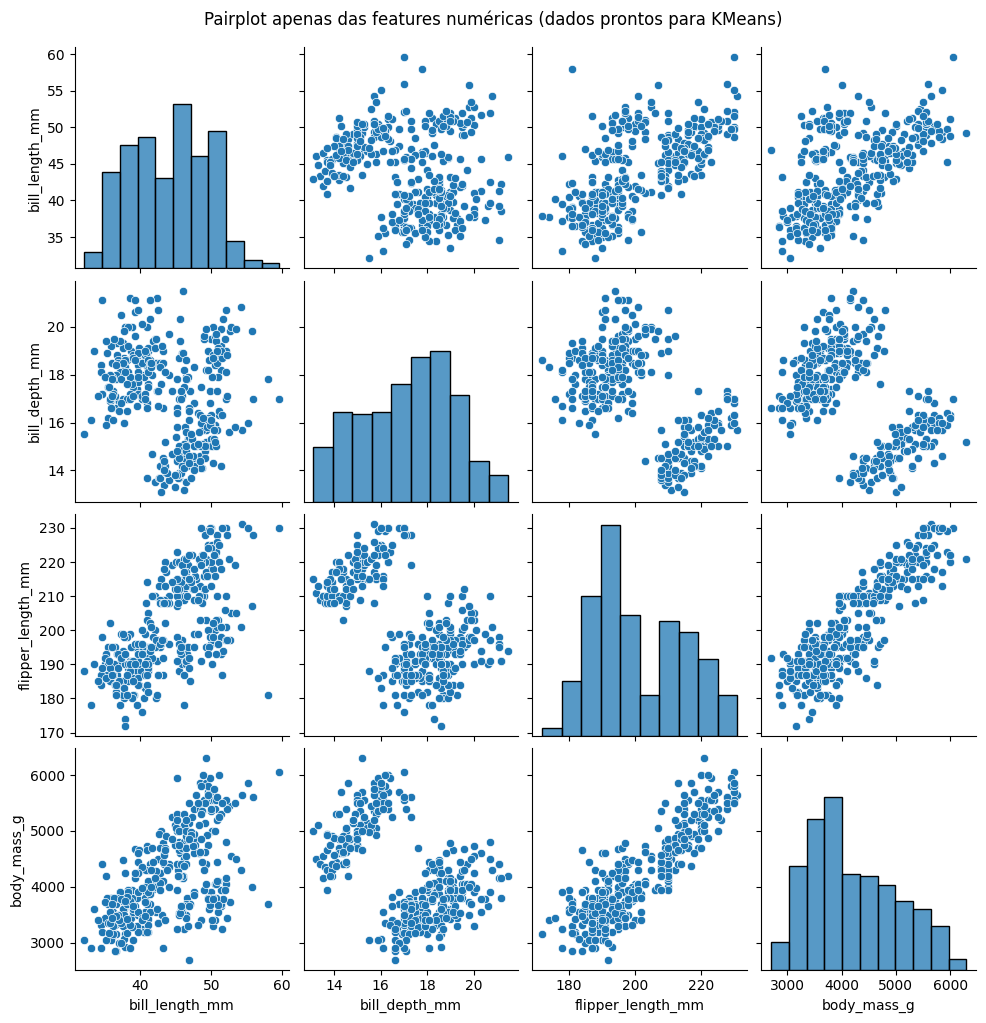

In [34]:
# pairplot com as espécies (para ver o "verdadeiro" agrupamento)
sns.pairplot(penguins.dropna(), hue='species', diag_kind='hist')
plt.suptitle('Pairplot com hue=species (dados originais)', y=1.02)
plt.show()

# pairplot só com as features numéricas (versão sem a coluna species)
sns.pairplot(df_num)
plt.suptitle('Pairplot apenas das features numéricas (dados prontos para KMeans)', y=1.02)
plt.show()

# 3 - Realize a padronização dos dados e visualize os dados.

In [ ]:
# Padronizar as features numéricas
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(df_num)
X_scaled = pd.DataFrame(X_scaled_arr, columns=df_num.columns, index=df_num.index)

# informação
print("Média por coluna (depois do scaler):\n", X_scaled.mean().round(6))
print("Desvio padrão (depois do scaler):\n", X_scaled.std(ddof=0).round(6))
X_scaled.head()

Média por coluna (depois do scaler):
 bill_length_mm       0.0
bill_depth_mm        0.0
flipper_length_mm    0.0
body_mass_g         -0.0
dtype: float64
Desvio padrão (depois do scaler):
 bill_length_mm       1.0
bill_depth_mm        1.0
flipper_length_mm    1.0
body_mass_g          1.0
dtype: float64


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
3,-1.335566,1.085877,-0.569284,-0.941606
4,-0.859415,1.747026,-0.783651,-0.692852


# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [36]:
# Aplicar KMeans (número de cluster k=3)

k = 3
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# criar dataframe com cluster label
df_clusters = df_num.copy()
df_clusters['cluster'] = labels

print("Contagem por cluster:\n", pd.Series(labels).value_counts().sort_index())
print("\nCentroides (no espaço padronizado):")
print(kmeans.cluster_centers_)

# opcional: juntar com df_clean para comparar com species
df_clusters_with_meta = df_clean.join(df_clusters[['cluster']], how='inner')
df_clusters_with_meta.head()

Contagem por cluster:
 0    129
1    119
2     85
Name: count, dtype: int64

Centroides (no espaço padronizado):
[[-1.04680889  0.48662566 -0.88169491 -0.7627539 ]
 [ 0.65475809 -1.10270671  1.16246305  1.10121078]
 [ 0.67202511  0.80526339 -0.28934658 -0.38410387]]


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,cluster
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0


# 5 - Construa pelo 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

**Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

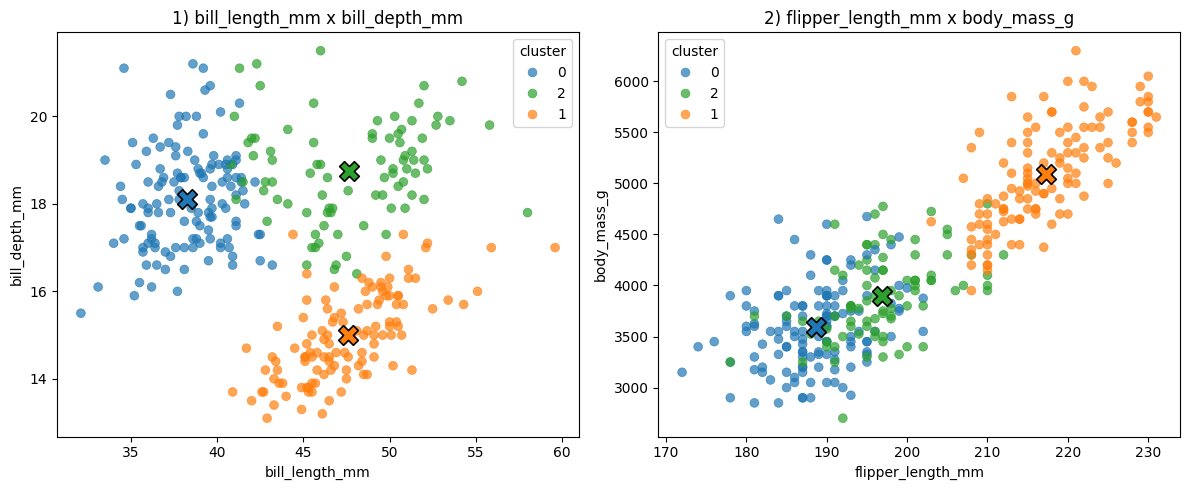

In [ ]:
# 1) carregar e preparar dados (não altera o original)
penguins = sns.load_dataset("penguins")
df_clean = penguins.copy().dropna().reset_index(drop=True)
df_num = df_clean.select_dtypes(include=['float64','int64']).copy()

# 2) padronizar e aplicar KMeans (k=3 como ponto de partida)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)
k = 3
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 3) preparar cores consistentes por cluster
labels_str = labels.astype(str)
unique = np.unique(labels_str)
palette_list = sns.color_palette("tab10", n_colors=len(unique))
palette = {lab: palette_list[i] for i, lab in enumerate(unique)}

# 4) calcular centróides no espaço original (para desenhar nos eixos originais)
centers_scaled = kmeans.cluster_centers
centers_orig = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_orig, columns=df_num.columns)

# 5) DataFrame para plot com labels
df_plot = df_num.copy()
df_plot['cluster'] = labels_str

# Função auxiliar para desenhar scatter + centróides
def scatter_with_centroids(x, y, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))
    sns.scatterplot(data=df_plot, x=x, y=y, hue='cluster', palette=palette, ax=ax, s=40, alpha=0.7, edgecolor=None)
    # sobrepor centróides (mesma cor do cluster)
    for lab in unique:
        c = int(lab)
        ax.scatter(centers_df.loc[c, x], centers_df.loc[c, y],
                   marker='X', s=200, color=palette[lab], edgecolor='black', linewidth=1.2, zorder=100)
    ax.set_title(title if title else f"{x} vs {y}")
    ax.legend(title='cluster')
    return ax

# 6) Plots solicitados
plt.figure(figsize=(12,5))

# Primeiro: bill_length_mm x bill_depth_mm
ax1 = plt.subplot(1,2,1)
scatter_with_centroids('bill_length_mm', 'bill_depth_mm', ax=ax1, title="1) bill_length_mm x bill_depth_mm")

# Segundo: flipper_length_mm x body_mass_g
ax2 = plt.subplot(1,2,2)
scatter_with_centroids('flipper_length_mm', 'body_mass_g', ax=ax2, title="2) flipper_length_mm x body_mass_g")

plt.tight_layout()
plt.show()

# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo:

Resposta:

Segue algumas utilizaçoes do algoritimo de clusterização:

1. Segmentação de clientes
Agrupa clientes com comportamentos parecidos (ex.: perfil de compra), permitindo criar campanhas e ofertas mais eficientes.

2. Detecção de anomalias
Identifica pontos que não pertencem a nenhum grupo ou ficam muito distantes dos demais, ajudando a detectar fraudes, erros ou valores atípicos.

3. Agrupamento de imagens ou documentos
Organiza automaticamente arquivos semelhantes (ex.: fotos parecidas, notícias sobre o mesmo tema) sem precisar de rótulos.